# 18 — Diagnosing HID-search-v2: search reach versus representation cost

Notebook 17 closed with an accepted, **inconclusive** prospective result: the full
automatic HID search neither beat nor lost to the nine-codec portfolio on the primary
population. This notebook asks *why it loses where it loses*, using four fixed
diagnostics on the strings that study already encoded:

* **D1** — where the bytes go, cell by cell, from the saved archives alone;
* **D2** — does giving the boundary stage B eight times its work caps find shorter archives?
* **D3** — over the *supplied* construction cuts (truth-assisted), is there a shorter
  partition in the unchanged leaf language, and can B's strict-improvement path reach it?
* **D4** — what does it cost to write the saved period / pair-grammar archives in HID?

Everything here is **post-hoc** on already inspected data. No result below is a new
confirmation, a superiority claim or a causal identification. Every number is printed
by a cell from a saved artifact.

**Corrected reporting revision `report-r2`.** The computations are the retained attempt
`a1`; the tables, flags and decision are regenerated from its saved records by a repaired
reporting pipeline (Codex review R1–R3). Two readings of the first version are withdrawn:
equal length $H=T$ is not the same proposal, and the distance of supplied cuts to the cuts
of B's *returned* archive is not a measure of which cuts B proposes. The first version of
this notebook is kept unchanged as a historical artifact.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
from pathlib import Path
_cands = [Path.cwd(), Path.cwd() / "index-deconvolution", Path(ROOT)]
ID_ROOT = next(p.resolve() for p in _cands
               if (p / "PROTOCOL_order_discovery.md").is_file()
               and (p / "results" / "hierarchy_search_diagnosis" / "search-diagnosis-v1-r1").is_dir())
ROOT = str(ID_ROOT)
for _p in (os.path.join(os.path.dirname(ROOT), "src"), ROOT):
    while _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("hierarchy", None)          # a sibling repo ships a module "hierarchy"
import json, hashlib, collections
import numpy as np
import matplotlib.pyplot as plt
from hierarchy.decode import decode_archive                 # saved archives only
from hierarchy.ledger import field_buckets

RUN = ID_ROOT / "results" / "hierarchy_search_diagnosis" / "search-diagnosis-v1-r1"
BASE = ID_ROOT / "results" / "hierarchy_search_v2" / "search-confirm-v2-r1"
R2 = ID_ROOT / "results" / "hierarchy_search_diagnosis" / "review_closure" / "search-diagnosis-v1-r1" / "report-r2"
def load(rel, root=RUN):
    return json.loads((root / rel).read_text())
identity, r2id = load("identity/identity.json"), load("identity.json", R2)
d1t, d1c, d1k = load("d1/d1_tables.json"), load("d1/d1_cases.json"), load("d1/d1_checks.json")
d2, s2 = load("outputs/d2_rows.json", R2), load("outputs/d2_summary.json", R2)
d3, d4, s4 = load("outputs/d3_rows.json", R2), load("outputs/d4_rows.json", R2), load("outputs/d4_summary.json", R2)
flags, res = load("outputs/flags.json", R2), load("outputs/resources.json", R2)
decision, kn = load("outputs/DECISION.json", R2), load("outputs/key_numbers.json", R2)
inputs = {r["case_id"]: r for r in map(json.loads, (RUN / "identity/input_manifest.jsonl").read_text().splitlines())}
def sha(b):
    return hashlib.sha256(b).hexdigest()
def input_bits(cid):
    """Bits of a case from its retained raw archive, checked against the input hash."""
    rows = {r["method"]: r for r in json.loads((BASE / "rows" / f"{cid}.json").read_text())}
    data = (BASE / rows["raw"]["archive_path"]).read_bytes()
    assert sha(data) == rows["raw"]["archive_sha256"]
    bits = decode_archive(data)
    assert sha(bits.encode()) == inputs[cid]["input_sha256"]
    return bits
print("run:", identity["run_id"], "| evidence role:", identity["evidence_role"])
print("identity:", identity["identity_sha256"][:16], "| baseline freeze:", identity["baseline_freeze_sha256"][:16])
print("membership:", identity["membership"])
print("reporting revision:", r2id["reporting_revision"], "| identity:", r2id["identity_sha256"][:16],
      "| computations:", r2id["compute_attempt"], r2id["compute_identity_sha256"][:16])

run: search-diagnosis-v1-r1 | evidence role: posthoc_diagnostic
identity: 518ebc137118643b | baseline freeze: 0f0a72ef2f9d9faa
membership: {'D1_cases': 1792, 'D2_controls': 32, 'D2_targets': 176, 'D3_strings': 176, 'D4_strings': 576}
reporting revision: report-r2 | identity: 89fa52872009f39b | computations: a1 518ebc137118643b


## 1. Identity, completeness and the accepted baseline

The diagnostic implementation identity covers the adapters, every imported owner, the
protocol packet, both boundary configurations and the fixed populations. D1 also
reproduces the **accepted** primary point estimate as a preservation check.

In [3]:
print("D1 checks:", d1k["cases"], "cases,", d1k["rows"], "rows, problems:", len(d1k["problems"]))
print("accepted primary estimate, recomputed from saved rows:", d1t["accepted_primary_reproduction"]["estimate"],
      "over", d1t["accepted_primary_reproduction"]["cells"], "cells")
for s, r in res.items():
    print(f"{s}: {r['jobs']} jobs, status {r['status']}, worker wall total {r['worker_wall_s_total']:.1f} s, "
          f"max {r['worker_wall_s_max']:.2f} s, peak RSS max {r['peak_rss_bytes_max'] / 2**20:.1f} MiB")
_rr = RUN / "identity" / "reporting_revisions.json"
if _rr.is_file():
    print("reporting-only revision after the jobs:", sorted(json.loads(_rr.read_text())["changed"]))

D1 checks: 1792 cases, 28672 rows, problems: 0
accepted primary estimate, recomputed from saved rows: 0.005605234982532739 over 21 cells
D2: 416 jobs, status {'ok': 416}, worker wall total 112.7 s, max 2.28 s, peak RSS max 65.7 MiB
D3: 176 jobs, status {'ok': 176}, worker wall total 11.7 s, max 0.16 s, peak RSS max 28.5 MiB
D4: 576 jobs, status {'ok': 576}, worker wall total 26.7 s, max 0.06 s, peak RSS max 26.2 MiB
reporting-only revision after the jobs: ['index-deconvolution/experiments/search_diagnosis/analysis.py', 'index-deconvolution/experiments/search_diagnosis/cli.py', 'index-deconvolution/experiments/search_diagnosis/report.py']


## 2. D1 — where the full method wins and loses

Saving is $(\text{bits(portfolio)} - \text{bits(hid\_full)})/n$: positive means HID is
shorter. Weighting: base/ragged pair mean, unit mean within each cell. Colour shows the
portfolio's most frequent winning codec in the cell.

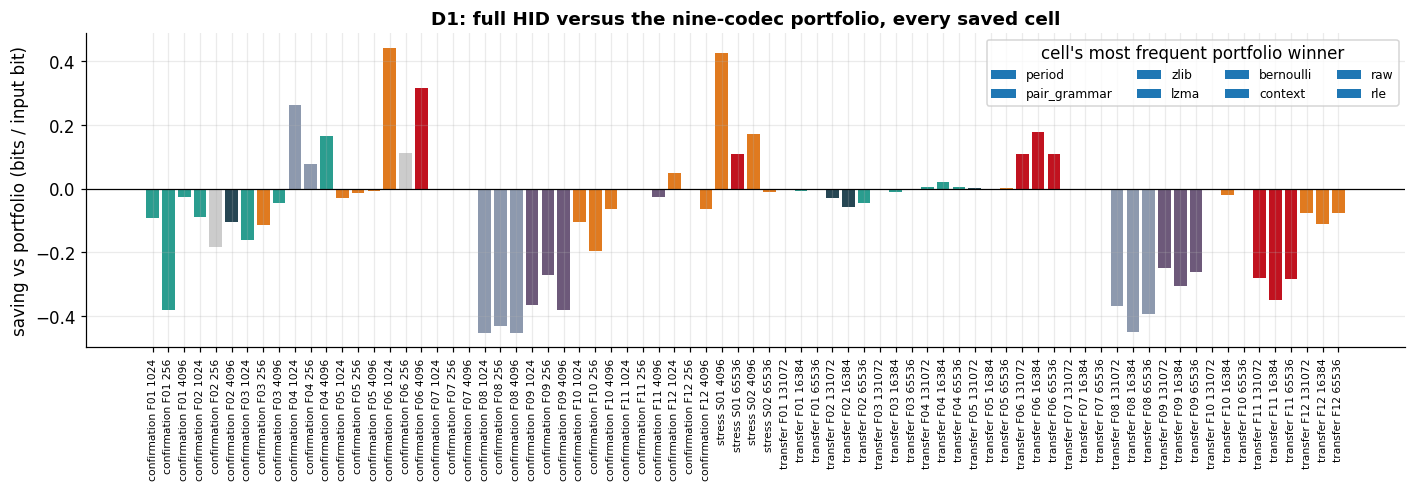

cells where hid_full is shorter on average: 18 of 76 | ties: 8 | portfolio shorter: 50


In [4]:
cells_ = d1t["cells"]
vals = [d1t["saving_full_vs_portfolio"][c]["mean"] for c in cells_]
top = [max(d1t["portfolio_winner_counts"][c].items(), key=lambda kv: kv[1])[0] for c in cells_]
pal = {"period": "#2a9d8f", "pair_grammar": "#264653", "zlib": "#e07a1f", "lzma": "#c1121f",
       "bernoulli": "#8d99ae", "context": "#6d597a", "raw": "#cccccc", "rle": "#b5838d"}
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.bar(range(len(cells_)), vals, color=[pal.get(t, "#999") for t in top])
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(cells_))); ax.set_xticklabels([c.replace("|", " ") for c in cells_], rotation=90, fontsize=7)
ax.set_ylabel("saving vs portfolio (bits / input bit)")
for t, col in pal.items():
    ax.bar([], [], color=col, label=t)
ax.legend(ncol=4, fontsize=8, title="cell's most frequent portfolio winner")
ax.set_title("D1: full HID versus the nine-codec portfolio, every saved cell")
plt.tight_layout(); plt.show()
print("cells where hid_full is shorter on average:", sum(v > 0 for v in vals), "of", len(vals),
      "| ties:", sum(v == 0 for v in vals), "| portfolio shorter:", sum(v < 0 for v in vals))

Two kinds of losing cell stand out: those where the portfolio's **period** (or pair
grammar) codec wins — families F01–F05 — and the boundary families **F12/S02**, where the
portfolio wins with **zlib**. D4 and D2/D3 address them respectively.

In [5]:
for c in ("confirmation|F01|256", "confirmation|F03|1024", "confirmation|F12|4096", "transfer|F12|65536"):
    b = {m: {k: round(per_cell[c], 4) for k, per_cell in d1t["bucket_bits_per_input_bit"][m].items() if per_cell[c]}
         for m in ("hid_full", "baseline_best")}
    print(c, "| winners", d1t["portfolio_winner_counts"][c], "| full stage", d1t["full_selected_stage_counts"][c])
    for m, v in b.items():
        print(f"   {m:<14}", v)

confirmation|F01|256 | winners {'period': 40} | full stage {'L': 40}
   hid_full       {'dag_count_opcodes': 0.146, 'envelope': 0.2486, 'literal_padding_bits': 0.0301, 'literal_payload_bits': 0.112, 'parameters': 0.1522, 'references': 0.0839}
   baseline_best  {'envelope': 0.2486, 'other_payload': 0.1429}
confirmation|F03|1024 | winners {'period': 40} | full stage {'L': 40}
   hid_full       {'dag_count_opcodes': 0.0675, 'envelope': 0.0624, 'literal_padding_bits': 0.0135, 'literal_payload_bits': 0.271, 'parameters': 0.0636, 'references': 0.0643}
   baseline_best  {'envelope': 0.0624, 'other_payload': 0.3198}
confirmation|F12|4096 | winners {'zlib': 40} | full stage {'B': 40}
   hid_full       {'dag_count_opcodes': 0.0182, 'envelope': 0.0176, 'literal_padding_bits': 0.0028, 'literal_payload_bits': 0.5262, 'parameters': 0.0182, 'references': 0.0154}
   baseline_best  {'envelope': 0.0176, 'other_payload': 0.5174}
transfer|F12|65536 | winners {'zlib': 8} | full stage {'L': 8}
   hid_full  

## 3. D2 — the B0→B8 cap increase changed one output

B0 is the frozen boundary stage; B8 has eight times the root-trial, leaf-cache and
leaf-length caps and nothing else changed. B0 must reproduce the saved B telemetry
exactly before B8 means anything. The result concerns this one cap increase on these
strings; it does not exclude resource limits under other searches.

In [6]:
for g in ("targets", "controls"):
    s = s2[g]
    print(f"{g}: B0 deterministic mismatches {len(s['B0_mismatch_cases'])}; B0 bytes = saved final (where B was selected) {s['B0_byte_identity']}")
    print(f"   B8 shorter than saved hid_full: {s['witnesses']}; equal-cell mean opportunity {s['equal_cell_mean_opportunity']}")
f = flags["budget_opportunity_observed"]
print("B0 cap-hit strings:", f["B0_cap_hit_strings"])
print("witness detail:", f["witnesses"])
print("controls where B8 differs from B0:", f["control_behaviour"]["B8_differs_from_B0"],
      "of", f["control_behaviour"]["comparable_controls"], "comparable controls")

targets: B0 deterministic mismatches 0; B0 bytes = saved final (where B was selected) {'None': 64, 'True': 112}
   B8 shorter than saved hid_full: ['stress-S02-4096-4001-ragged']; equal-cell mean opportunity 7.623810685533057e-05
controls: B0 deterministic mismatches 0; B0 bytes = saved final (where B was selected) {'None': 32}
   B8 shorter than saved hid_full: []; equal-cell mean opportunity 0.0
B0 cap-hit strings: ['stress-S02-4096-4001-ragged', 'stress-S02-65536-4000-ragged', 'transfer-F12-131072-5000-base']
witness detail: [{'B0': 2392, 'B0_stop': 'root_trial_cap', 'B8': 2352, 'B8_stop': 'no_strict_improvement', 'H': 2392, 'case_id': 'stress-S02-4096-4001-ragged', 'n': 4099, 'portfolio': 3088}]
controls where B8 differs from B0: 0 of 32 comparable controls


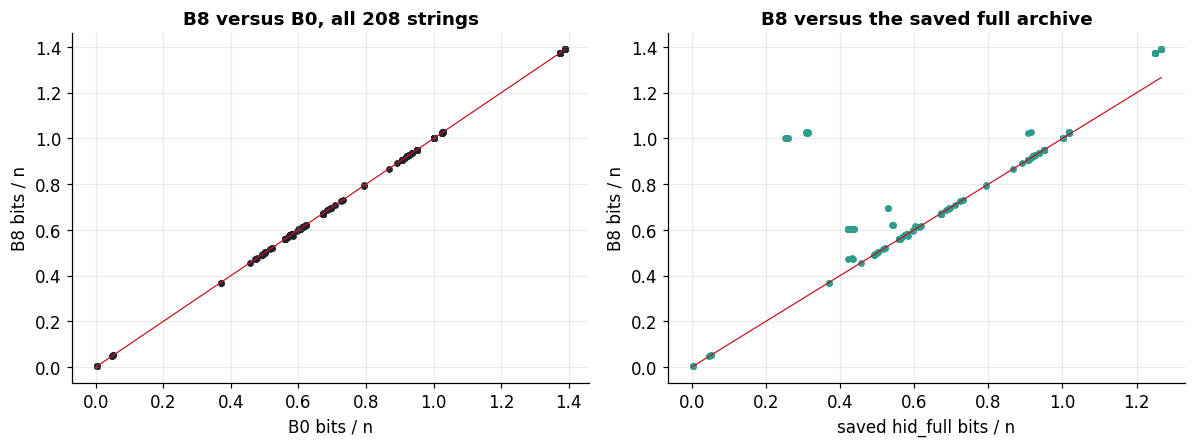

strings with B8 != B0: 1 of 208


In [7]:
x = np.array([d2[c]["B0_bits"] / d2[c]["n"] for c in d2]); y = np.array([d2[c]["B8_bits"] / d2[c]["n"] for c in d2])
h = np.array([d2[c]["H"] / d2[c]["n"] for c in d2])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.scatter(x, y, s=12, color=INK); a1.plot([0, x.max()], [0, x.max()], color=HL, lw=0.8)
a1.set_xlabel("B0 bits / n"); a1.set_ylabel("B8 bits / n"); a1.set_title("B8 versus B0, all 208 strings")
a2.scatter(h, y, s=12, color=OK); a2.plot([0, h.max()], [0, h.max()], color=HL, lw=0.8)
a2.set_xlabel("saved hid_full bits / n"); a2.set_ylabel("B8 bits / n"); a2.set_title("B8 versus the saved full archive")
plt.tight_layout(); plt.show()
print("strings with B8 != B0:", int((x != y).sum()), "of", len(x))

## 4. D3 — the supplied-cut subset space (truth-assisted)

For each of the 176 boundary-family strings, the retained construction cuts (at most
five) give at most 32 partitions. Each is priced as a complete archive by the unchanged
B leaf builder and serializer. An edge adds one cut; it is **eligible** when the split
segment is at least 64 bits, and **strict** when it also shortens the archive. Below,
one string's whole space is drawn: every partition, every edge, the saved full archive
and the portfolio.

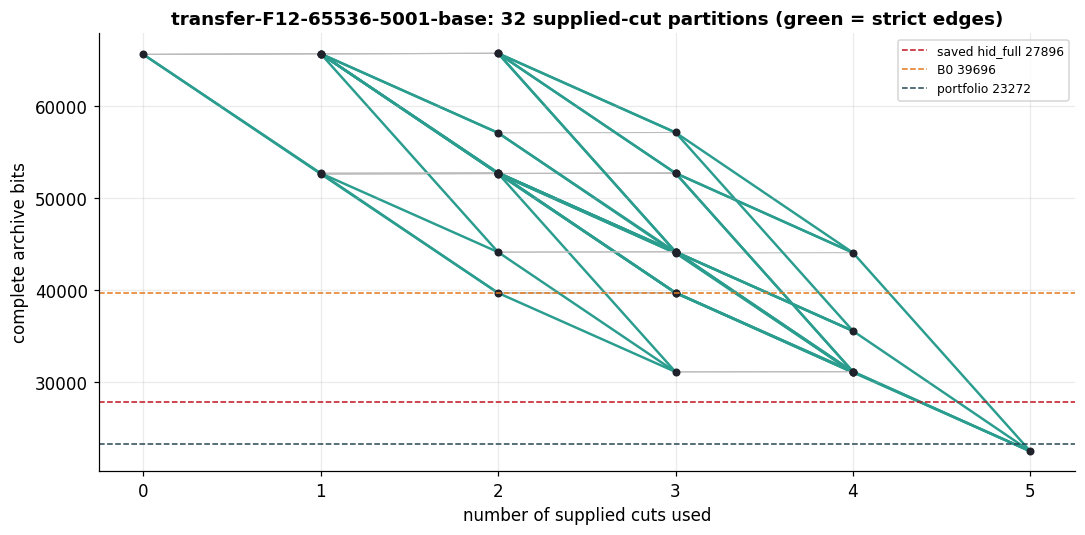

archives re-decoded: 32 | cheapest all / eligible / strict: {'bits': 22480, 'subset': [13107, 13108, 21847, 43693, 52431]} {'bits': 22480, 'subset': [13107, 13108, 21847, 43693, 52431]} {'bits': 31120, 'subset': [13107, 43693, 52431]} | barrier: {'equality_edges': 0, 'frontier_edges': 14, 'kind': 'positive_cost_step', 'min_delta_bits': 8, 'positive_edges': 14}


In [8]:
_bar = sorted(c for c, r in d3.items() if r["restricted_path_barrier"] and c.startswith("transfer-F12-65536"))
cid = _bar[0] if _bar else sorted(d3)[0]
rec = json.loads((RUN / "jobs" / "D3" / f"{cid}.D3.json").read_text())
bits = input_bits(cid)
cost = {tuple(s["subset"]): s["archive_bits"] for s in rec["info"]["subsets"]}
_ok = 0                                                                # re-check every archive
for s in rec["info"]["subsets"]:
    p = next(RUN.glob(f"archives/{s['archive_sha256'][:2]}/{s['archive_sha256']}.isd"))
    data = p.read_bytes(); assert sha(data) == s["archive_sha256"] and decode_archive(data) == bits; _ok += 1
r = d3[cid]; P = d1c[cid]["bits"]["baseline_best"]
fig, ax = plt.subplots(figsize=(10, 5))
for e in r["edges"]:
    a, b = tuple(e["from"]), tuple(e["to"])
    if e["eligible"]:
        ax.plot([len(a), len(b)], [cost[a], cost[b]], color=OK if e["strict"] else "#bbbbbb",
                lw=1.6 if e["strict"] else 0.7, zorder=1)
ax.scatter([len(s) for s in cost], list(cost.values()), color=INK, s=18, zorder=2)
for lab, v, col in (("saved hid_full", r["H"], HL), ("B0", r["B0"], BAD), ("portfolio", P, "#264653")):
    ax.axhline(v, color=col, ls="--", lw=1, label=f"{lab} {v}")
ax.set_xlabel("number of supplied cuts used"); ax.set_ylabel("complete archive bits")
ax.set_title(f"{cid}: 32 supplied-cut partitions (green = strict edges)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("archives re-decoded:", _ok, "| cheapest all / eligible / strict:",
      r["cheapest_all"], r["cheapest_eligible"], r["cheapest_strict"], "| barrier:", r.get("barrier"))

In [9]:
fb = flags["restricted_path_barrier_observed"]
print("space:", fb["space"]); print("barrier kinds:", fb["barrier_kinds"], "| eligibility obstructions:", fb["eligibility_obstructions"])
print("denominator:", fb["denominator"])
keys = ["strings", "reference_reproduced", "H_gt_portfolio", "cheapest_all_lt_H", "cheapest_strict_lt_H",
        "cheapest_all_lt_portfolio", "cheapest_strict_lt_portfolio", "restricted_path_barrier"]
print(f"{'cell':<24}" + "".join(f"{k[:22]:>24}" for k in keys))
for c, v in fb["by_cell"].items():
    print(f"{c:<24}" + "".join(f"{v.get(k, 0):>24}" for k in keys))
prox = fb["descriptive_returned_B0_cut_proximity"]
print("descriptive, post hoc -- proximity to the cuts of B0's RETURNED archive (not proposal coverage):")
print("   strings:", prox["strings"], "| supplied cuts with a returned B0 cut within 8 bits:",
      prox["supplied_cut_with_returned_B0_cut_within_8_bits"], "| without:",
      prox["supplied_cut_without_returned_B0_cut_within_8_bits"])

space: D3 supplied-cut subsets only (truth-assisted, B0 leaf heuristic)
barrier kinds: {'positive_cost_step': 22} | eligibility obstructions: 0
denominator: {'available_strings': 176, 'strings': 176, 'subsets': 5632}
cell                                     strings    reference_reproduced          H_gt_portfolio       cheapest_all_lt_H    cheapest_strict_lt_H  cheapest_all_lt_portfo  cheapest_strict_lt_por  restricted_path_barrie
confirmation|F12|1024                         40                      40                       0                       9                       9                      28                      28                       0
confirmation|F12|256                          40                      40                       0                       0                       0                       0                       0                       0
confirmation|F12|4096                         40                      40                      40                      40            

## 5. D4 — writing the saved baseline proposals in HID

Each saved period and pair-grammar archive is rewritten as an HID graph with the existing
factory and serializer, and decoded. With $H$ the saved full-HID bits, $T$ the
translation and $C$ the saved baseline, $H-C=(H-T)+(T-C)$ holds exactly. $H>T$ would be a
same-language description the search missed; $T>C$ is this proposal's cost in HID.
$H=T$ compares **lengths**: there $H-C=T-C$ exactly, but the saved full archive need not
be the translated proposal, so byte identity is counted separately.

In [10]:
_n = 0
for key, r in d4.items():
    rec = json.loads((RUN / "jobs" / "D4" / f"{r['case_id']}.D4.json").read_text())
    a = rec["archives"][r["method"]]
    data = (RUN / a["path"]).read_bytes()
    assert sha(data) == a["sha256"] and 8 * len(data) == r["T"] and field_buckets(data) == r["translated_buckets"]
    _n += 1
print("translated archives re-hashed and re-bucketed:", _n)
for m in ("period", "pair_grammar"):
    print(m, "| admissible", s4[m]["admissible"], "| T < H:", len(s4[m]["missed_witnesses"]),
          "| T > C:", s4[m]["penalty_cases"], "| identity failures:", s4[m]["identity_failures"])
print("absolute T - C bits:", flags["proposal_representation_penalty_observed"]["absolute_T_minus_C_bits"])

translated archives re-hashed and re-bucketed:

 1152
period | admissible 576 | T < H: 0 | T > C: 576 | identity failures: []
pair_grammar | admissible 576 | T < H: 0 | T > C: 576 | identity failures: []
absolute T - C bits: {'pair_grammar': {'max': 10656, 'median': 472.0, 'min': 200, 'n': 576}, 'period': {'max': 6160, 'median': 96.0, 'min': 16, 'n': 576}}


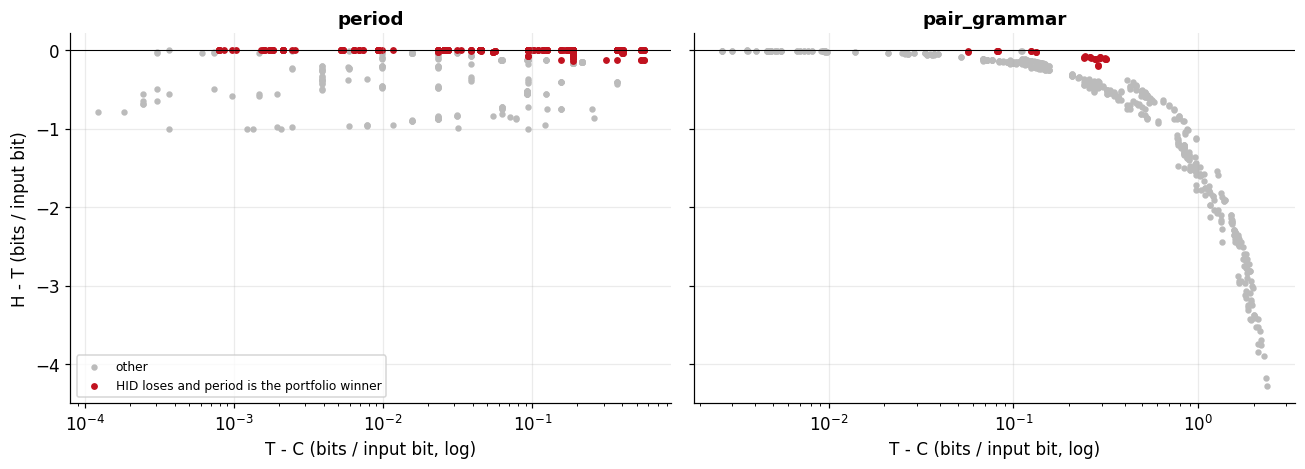

strings where the translated method won the portfolio: 386 | HID loses: 367 | of which H == T: 282 | H < T: 85
equal length H == T: 282 | byte-identical: 261 | same length, different bytes: 21 | translation unavailable: 0


In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, m in zip(axs, ("period", "pair_grammar")):
    rows = [r for r in d4.values() if r["method"] == m]
    ht = np.array([r["H_minus_T"] / r["n"] for r in rows]); tc = np.array([r["T_minus_C"] / r["n"] for r in rows])
    lose = np.array([r["H"] > r["portfolio"] and r["portfolio_method"] == m for r in rows])
    ax.scatter(tc[~lose], ht[~lose], s=10, color="#bbbbbb", label="other")
    ax.scatter(tc[lose], ht[lose], s=12, color=HL, label=f"HID loses and {m} is the portfolio winner")
    ax.axhline(0, color="k", lw=0.7); ax.set_xscale("log")
    ax.set_xlabel("T - C (bits / input bit, log)"); ax.set_title(m)
axs[0].set_ylabel("H - T (bits / input bit)"); axs[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
dec = flags["d4_loss_decomposition_where_portfolio_winner_was_translated"]
tot = collections.Counter()
for v in dec["by_cell"].values():
    tot.update(v)
print("strings where the translated method won the portfolio:", tot["portfolio_winner_period"] + tot["portfolio_winner_pair_grammar"],
      "| HID loses:", tot["hid_loses"], "| of which H == T:", tot["hid_loses_and_H_eq_T"], "| H < T:", tot["hid_loses_and_H_lt_T"])
print("equal length H == T:", tot["hid_loses_and_H_eq_T"], "| byte-identical:", tot["hid_loses_and_H_eq_T_identical_bytes"],
      "| same length, different bytes:", tot["hid_loses_and_H_eq_T_different_bytes"],
      "| translation unavailable:", tot["hid_loses_translation_unavailable"])

## 6. Flags and recommendation

The four flags may coexist; none authorizes an algorithm by itself. The recommendation
and its reasoning are in `DECISION.md`; the cell below prints the saved decision record.

In [12]:
for k, v in flags.items():
    if "value" in v:
        print(f"{k:<45} {v['value']}")
print()
print("evidence: complete", decision["complete"], "| valid", decision["valid"],
      "| unavailable", decision["gates"]["unavailable"])
print("recommendation:", decision["recommendation"])
for line in decision["basis"]:
    print(" -", line)

budget_opportunity_observed                   True
missed_baseline_structure_observed            False
proposal_representation_penalty_observed      True
restricted_path_barrier_observed              True

evidence: complete True | valid True | unavailable {'D2': {}, 'D3': {}, 'D4_conversions': {}, 'D4_jobs': {}}
recommendation: BOTH_SEPARATELY
 - D2: the B0 -> B8 cap increase changed the boundary output on 1 of 176 completed targets (176 intended) and on 0 of 32 comparable controls (32 intended); B0 hit a cap on 3 strings.
 - D3 (truth-assisted, 176 of 176 strings available): in 72 boundary-family strings where hid_full loses to the portfolio, a supplied-cut partition is shorter than the saved full archive in 72; restricted path barriers in 22 strings ({'positive_cost_step': 22}), eligibility obstructions 0.
 - D4: 367 strings where HID loses and the portfolio winner was the translated method; equal length H == T in 282 (byte-identical 261, different bytes 21), H < T in 85, translatio

## What this diagnosis can and cannot say

* **Post-hoc, inspected data.** Every string here was already encoded and inspected; any
  improvement is a diagnostic witness, not evidence of a better method.
* **D3 uses the generator's cuts.** Its partitions are metadata-assisted, restricted to
  at most five supplied cuts and to B's shortest-period leaf heuristic. It is not an
  optimal segmentation, not a bound over HID, and not proof that every automatic path
  meets the same barrier.
* **D4 is proposal-specific.** $T-C$ is the cost of this translation of this saved
  archive. It does not show that no better HID description exists, and $H-T$, $T-C$ are
  not a causal decomposition of the accepted primary estimate. $H=T$ is equality of
  length, not of proposal, and gives no exact prediction of the full method's $H$ under a
  changed representation: the incumbent, proposals or search path can differ.
* **Returned cuts are not proposed cuts.** The proximity count in §4 reads the cut tuple
  of the archive B0 returned. A cut may have been proposed and rejected; the statistic
  cannot rank proposal location, accepted path, refinement and leaf construction as causes.
* **D2 is boundary-only.** B8 is a probe of one cap increase, not a deployable
  full-wrapper encoder, and not a universal exclusion of resource limits.